In [1]:
print("Hello Shopper Spectrum")

Hello Shopper Spectrum


In [3]:
import pandas as pd

df = pd.read_csv("data/online_retail.csv")

print(df.shape)

(541909, 8)


In [3]:
import pandas as pd

df = pd.read_csv("../data/online_retail.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../data/online_retail.csv'

In [4]:
import pandas as pd

df = pd.read_csv("data/online_retail.csv")

In [5]:
print(df.shape)

(541909, 8)


In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 69.3 MB


In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
df = df.dropna(subset=['CustomerID'])

In [10]:
print(df.shape)

(406829, 8)


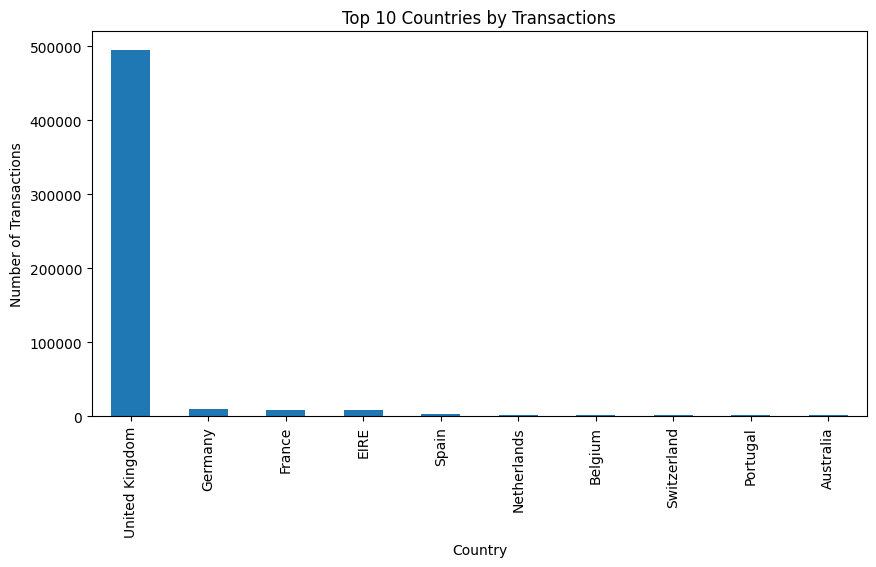

In [4]:
import matplotlib.pyplot as plt

country_counts = df['Country'].value_counts().head(10)

plt.figure(figsize=(10,5))
country_counts.plot(kind='bar')
plt.title('Top 10 Countries by Transactions')
plt.xlabel('Country')
plt.ylabel('Number of Transactions')
plt.show()

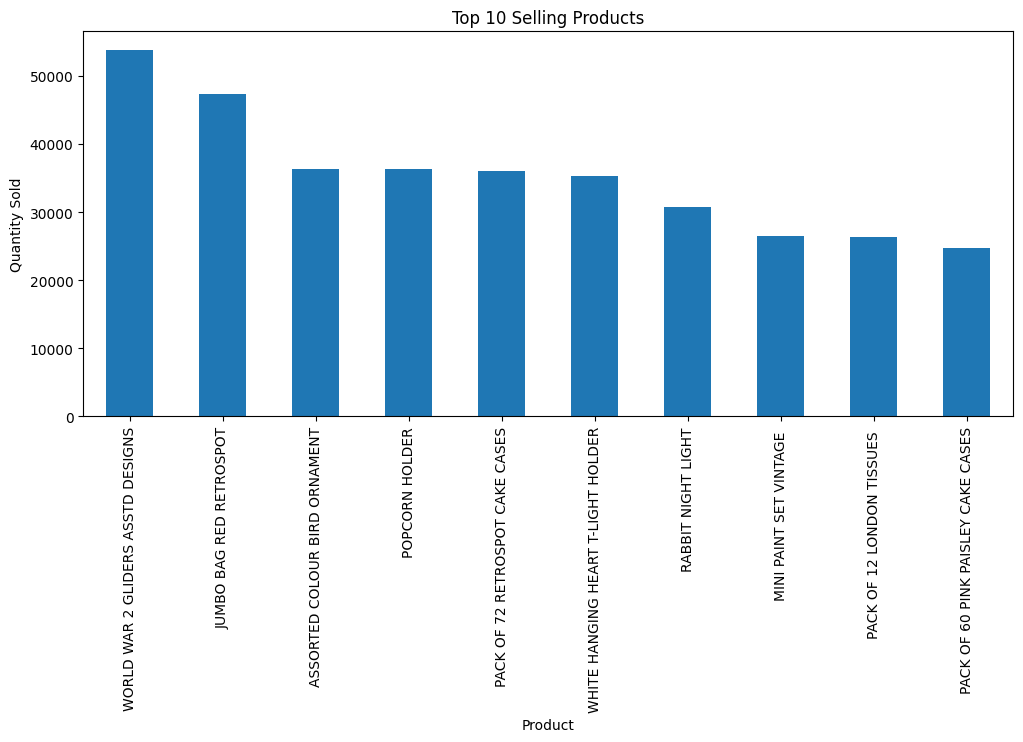

In [5]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))
top_products.plot(kind='bar')

plt.title('Top 10 Selling Products')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')

plt.show()

In [6]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = df.groupby('Month')['TotalAmount'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot()

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.show()

AttributeError: Can only use .dt accessor with datetimelike values

In [7]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [8]:
df['InvoiceDate'].dtype

dtype('<M8[us]')

In [9]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = df.groupby('Month')['TotalAmount'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot()

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.show()

KeyError: 'Column not found: TotalAmount'

In [10]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Month'],
      dtype='str')


In [11]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [12]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Month', 'TotalAmount'],
      dtype='str')


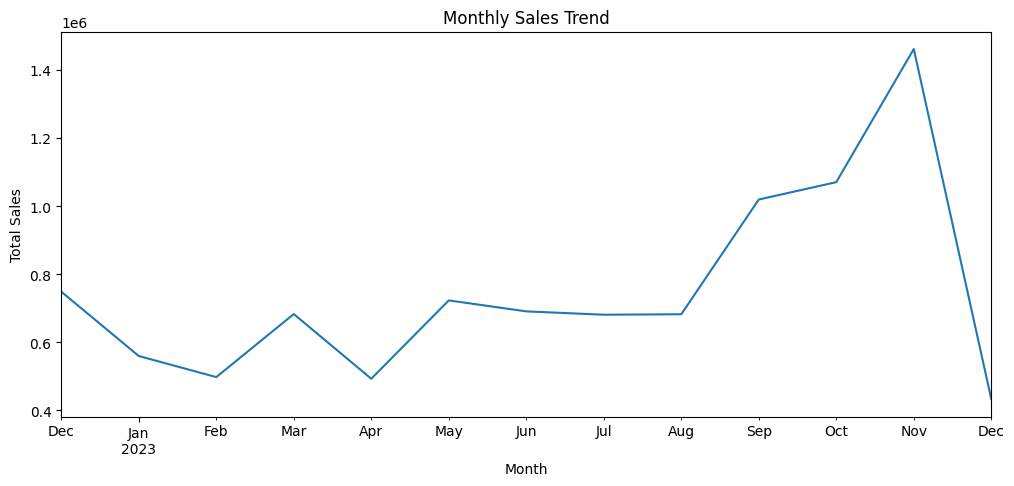

In [13]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = df.groupby('Month')['TotalAmount'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot()

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.show()

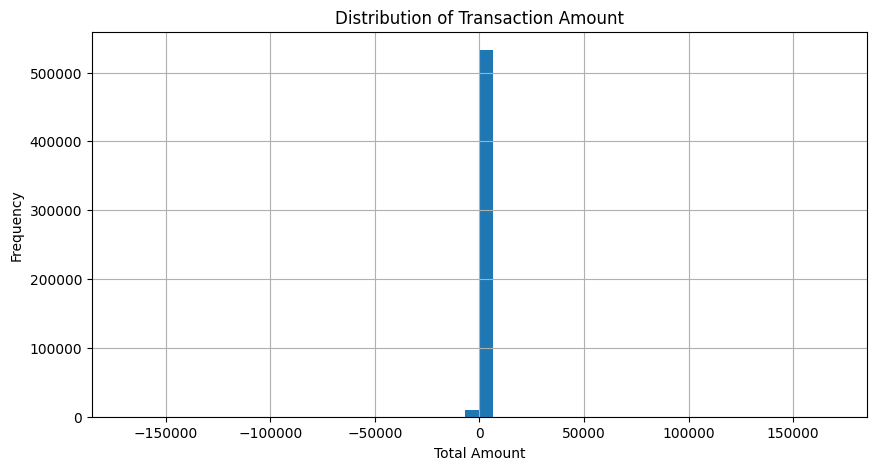

In [14]:
plt.figure(figsize=(10,5))

df['TotalAmount'].hist(bins=50)

plt.title('Distribution of Transaction Amount')
plt.xlabel('Total Amount')
plt.ylabel('Frequency')

plt.show()

In [15]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(snapshot_date)

2023-12-10 12:50:00


In [16]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

In [17]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

In [20]:
print(rfm_scaled[:5])

[[ 2.32202285 -0.32936215 -0.23100099]
 [-0.89373323  0.20610242  0.29343167]
 [-0.1691956  -0.11517632 -0.01231622]
 [-0.72500529 -0.43645506 -0.01714563]
 [ 2.16322008 -0.43645506 -0.19031183]]


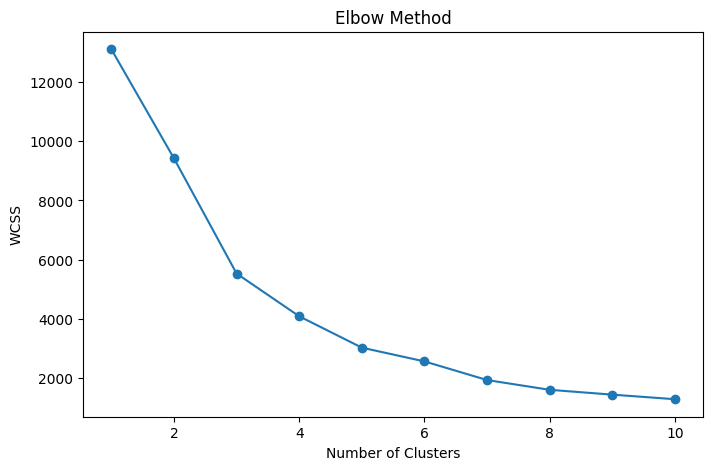

In [21]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

In [22]:
kmeans = KMeans(n_clusters=4, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,2,0.00,1
12347.0,2,7,4310.00,3
12348.0,75,4,1797.24,3
12349.0,19,1,1757.55,3
12350.0,310,1,334.40,1


In [23]:
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,10.752577,28.510309,12168.264691
1,248.927577,1.805942,455.110716
2,5.090909,109.909091,124312.306364
3,42.780906,4.370550,1320.981506


In [24]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,2,0.00,1
12347.0,2,7,4310.00,3
12348.0,75,4,1797.24,3
12349.0,19,1,1757.55,3
12350.0,310,1,334.40,1


In [25]:
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,10.752577,28.510309,12168.264691
1,248.927577,1.805942,455.110716
2,5.090909,109.909091,124312.306364
3,42.780906,4.370550,1320.981506


In [26]:
cluster_names = {
    0: 'Loyal Customers',
    1: 'At Risk Customers',
    2: 'VIP Customers',
    3: 'Regular Customers'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_names)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,2,0.00,1,At Risk Customers
12347.0,2,7,4310.00,3,Regular Customers
12348.0,75,4,1797.24,3,Regular Customers
12349.0,19,1,1757.55,3,Regular Customers
12350.0,310,1,334.40,1,At Risk Customers


In [27]:
rfm['Segment'].value_counts()

Segment
Regular Customers    3090
At Risk Customers    1077
Loyal Customers       194
VIP Customers          11
Name: count, dtype: int64

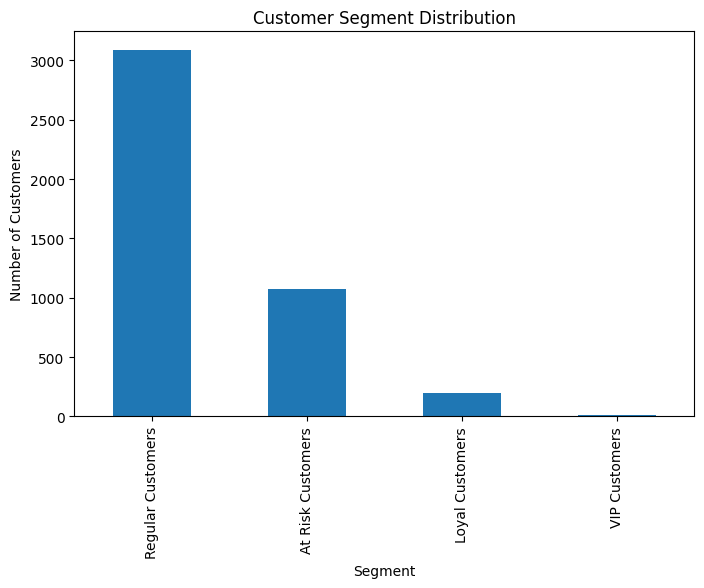

In [28]:
import matplotlib.pyplot as plt

rfm['Segment'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Customer Segment Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')

plt.show()

In [29]:
rfm.to_csv("models/customer_segments.csv")

In [30]:
customer_product_matrix = df.pivot_table(
    index='CustomerID',
    columns='Description',
    values='Quantity',
    fill_value=0
)

customer_product_matrix.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12347.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12348.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12349.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12350.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
from sklearn.metrics.pairwise import cosine_similarity

In [32]:
product_similarity = cosine_similarity(
    customer_product_matrix.T
)

In [33]:
product_similarity_df = pd.DataFrame(
    product_similarity,
    index=customer_product_matrix.columns,
    columns=customer_product_matrix.columns
)

product_similarity_df.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
Description,,,,,,,,,,,,,,,,,,,,,
4 PURPLE FLOCK DINNER CANDLES,1.000000,0.000000,0.000000,0.000494,0.000000,0.000000,0.031809,0.000000,0.000272,0.134904,...,0.0,0.002012,0.028772,0.002469,0.0,0.006003,0.0,0.039492,0.00000,0.001852
50'S CHRISTMAS GIFT BAG LARGE,0.000000,1.000000,0.009132,0.004512,0.000000,0.020511,0.016846,0.919223,0.145911,0.008435,...,0.0,0.001864,0.021638,0.011984,0.0,0.015008,0.0,0.010457,0.00000,0.031389
DOLLY GIRL BEAKER,0.000000,0.009132,1.000000,0.536503,0.728954,0.017901,0.005123,0.007489,0.002646,0.187001,...,0.0,0.000174,0.009874,0.369115,0.0,0.252355,0.0,0.456007,0.00036,0.015570
I LOVE LONDON MINI BACKPACK,0.000494,0.004512,0.536503,1.000000,0.705221,0.025421,0.001174,0.004645,0.007067,0.172442,...,0.0,0.001621,0.008344,0.354292,0.0,0.239958,0.0,0.454081,0.00000,0.016661
I LOVE LONDON MINI RUCKSACK,0.000000,0.000000,0.728954,0.705221,1.000000,0.000000,0.000000,0.000000,0.000000,0.214024,...,0.0,0.000000,0.000000,0.492357,0.0,0.331059,0.0,0.616895,0.00000,0.000000


In [34]:
def recommend_products(product_name, n=5):

    similar_products = product_similarity_df[product_name].sort_values(
        ascending=False
    )

    return similar_products.iloc[1:n+1]

In [35]:
print(df['Description'].dropna().unique()[:20])

<ArrowStringArray>
[ 'WHITE HANGING HEART T-LIGHT HOLDER',                 'WHITE METAL LANTERN',
      'CREAM CUPID HEARTS COAT HANGER', 'KNITTED UNION FLAG HOT WATER BOTTLE',
      'RED WOOLLY HOTTIE WHITE HEART.',        'SET 7 BABUSHKA NESTING BOXES',
   'GLASS STAR FROSTED T-LIGHT HOLDER',              'HAND WARMER UNION JACK',
           'HAND WARMER RED POLKA DOT',       'ASSORTED COLOUR BIRD ORNAMENT',
          'POPPY'S PLAYHOUSE BEDROOM ',           'POPPY'S PLAYHOUSE KITCHEN',
   'FELTCRAFT PRINCESS CHARLOTTE DOLL',             'IVORY KNITTED MUG COSY ',
  'BOX OF 6 ASSORTED COLOUR TEASPOONS',       'BOX OF VINTAGE JIGSAW BLOCKS ',
      'BOX OF VINTAGE ALPHABET BLOCKS',            'HOME BUILDING BLOCK WORD',
            'LOVE BUILDING BLOCK WORD',         'RECIPE BOX WITH METAL HEART']
Length: 20, dtype: str


In [36]:
recommend_products('WHITE HANGING HEART T-LIGHT HOLDER')

Description
GIN + TONIC DIET METAL SIGN           0.705896
TEA TIME TEA TOWELS                   0.644092
FAIRY CAKE FLANNEL ASSORTED COLOUR    0.593583
RED HANGING HEART T-LIGHT HOLDER      0.539690
DOORMAT FAIRY CAKE                    0.515421
Name: WHITE HANGING HEART T-LIGHT HOLDER, dtype: float64

In [37]:
product_similarity_df.to_csv("models/product_similarity.csv")

In [38]:
import os

os.makedirs("models", exist_ok=True)

In [39]:
rfm.to_csv("models/customer_segments.csv")

In [40]:
product_similarity_df.to_csv("models/product_similarity.csv")

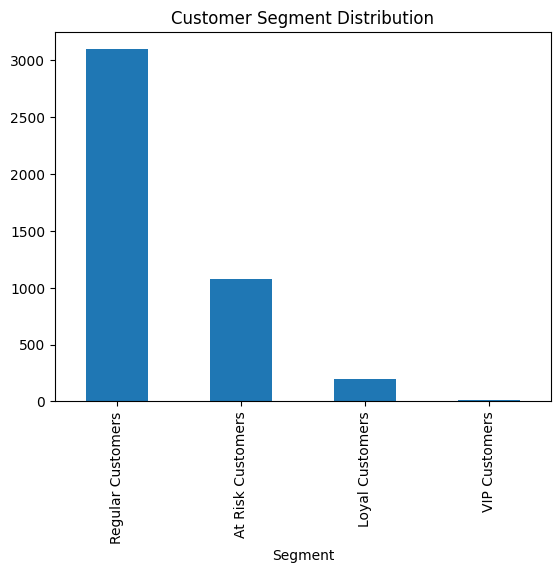

In [41]:
rfm['Segment'].value_counts().plot(kind='bar')
plt.title('Customer Segment Distribution')
plt.show()

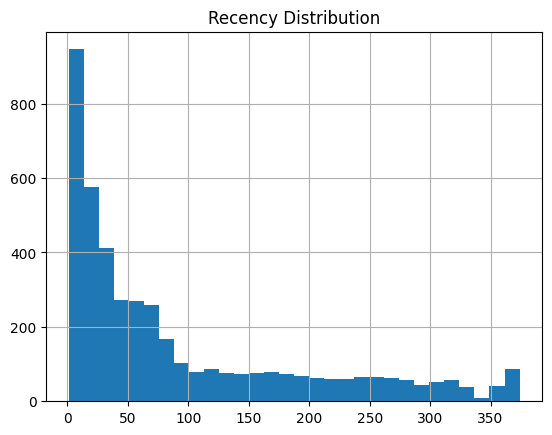

In [42]:
rfm['Recency'].hist(bins=30)
plt.title('Recency Distribution')
plt.show()

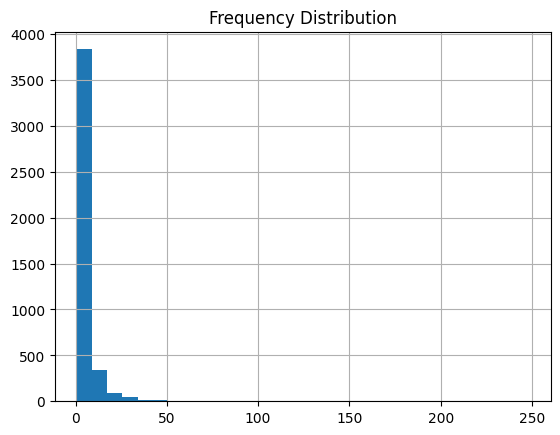

In [43]:
rfm['Frequency'].hist(bins=30)
plt.title('Frequency Distribution')
plt.show()

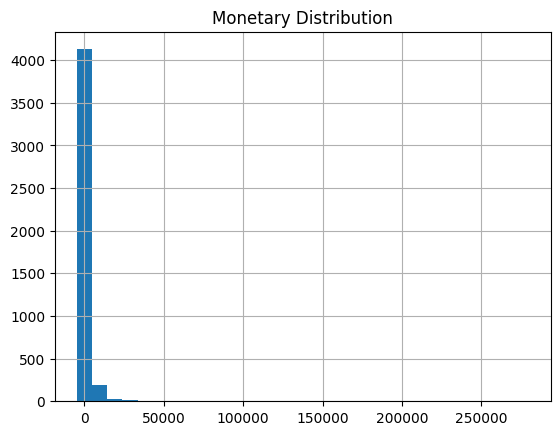

In [44]:
rfm['Monetary'].hist(bins=30)
plt.title('Monetary Distribution')
plt.show()

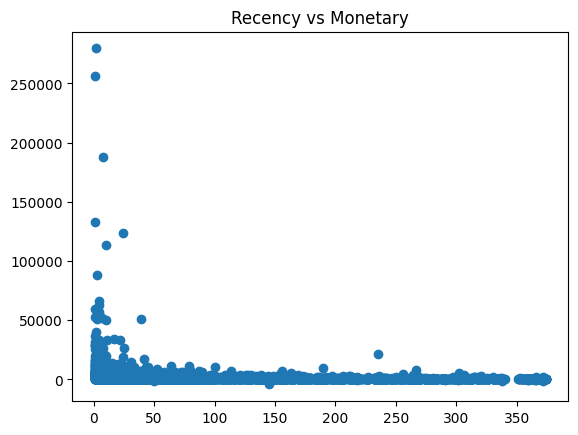

In [45]:
plt.scatter(rfm['Recency'], rfm['Monetary'])
plt.title('Recency vs Monetary')
plt.show()

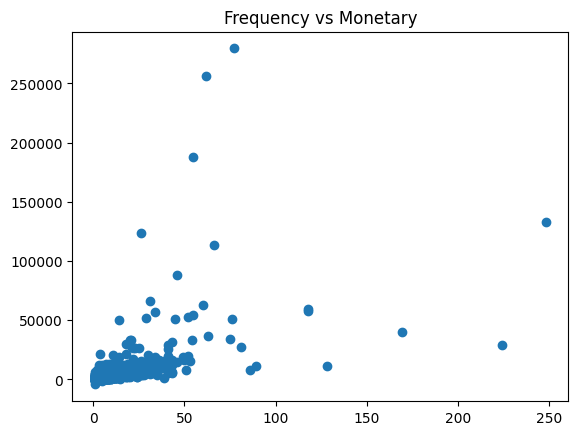

In [46]:
plt.scatter(rfm['Frequency'], rfm['Monetary'])
plt.title('Frequency vs Monetary')
plt.show()

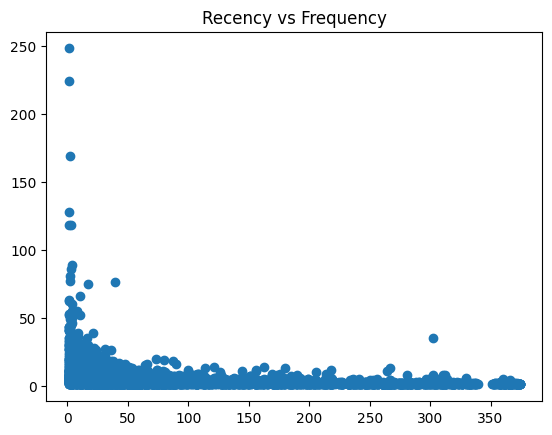

In [47]:
plt.scatter(rfm['Recency'], rfm['Frequency'])
plt.title('Recency vs Frequency')
plt.show()

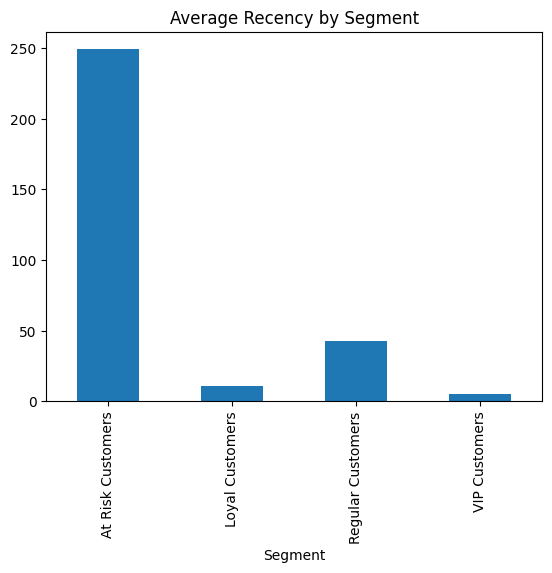

In [48]:
rfm.groupby('Segment')['Recency'].mean().plot(kind='bar')
plt.title('Average Recency by Segment')
plt.show()

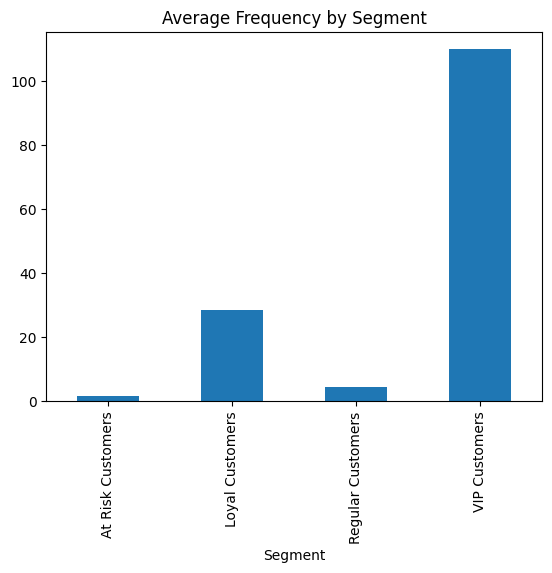

In [49]:
rfm.groupby('Segment')['Frequency'].mean().plot(kind='bar')
plt.title('Average Frequency by Segment')
plt.show()

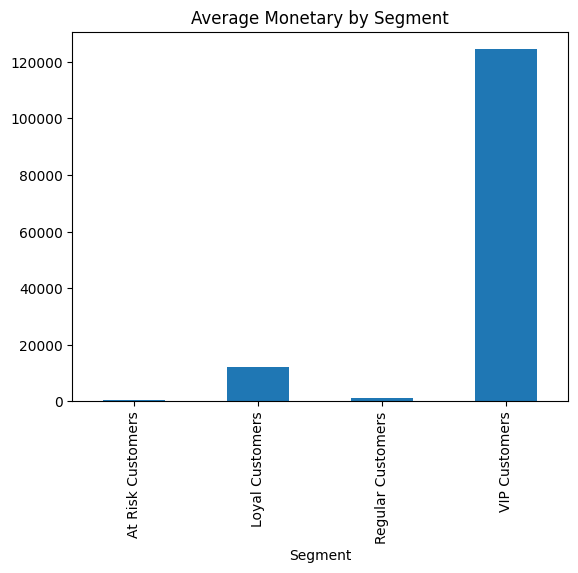

In [50]:
rfm.groupby('Segment')['Monetary'].mean().plot(kind='bar')
plt.title('Average Monetary by Segment')
plt.show()

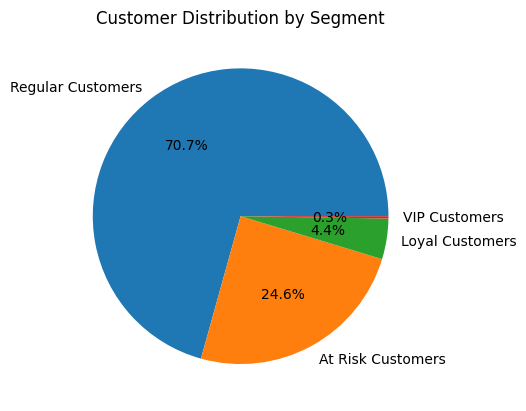

In [51]:
rfm['Segment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Customer Distribution by Segment')
plt.show()

# Shopper Spectrum Project

## 1. Problem Statement

## 2. Data Collection

## 3. Data Understanding

## 4. Data Cleaning

## 5. Exploratory Data Analysis (EDA)

## 6. Feature Engineering (RFM)

## 7. Data Scaling

## 8. KMeans Clustering

## 9. Customer Segmentation

## 10. Product Recommendation System

## 11. Results and Insights

## 12. Conclusion

### Results and Insights

* The dataset was cleaned and analyzed using exploratory data analysis techniques.
* RFM (Recency, Frequency, Monetary) analysis was performed to understand customer behavior.
* Customers were segmented using KMeans clustering into four groups:

  * VIP Customers
  * Loyal Customers
  * Regular Customers
  * At Risk Customers
* Customer distribution:

  * Regular Customers: 3090
  * At Risk Customers: 1077
  * Loyal Customers: 194
  * VIP Customers: 11
* A product recommendation system was developed using cosine similarity to suggest related products.
* Multiple visualizations were created to understand customer purchasing patterns and segment characteristics.


### Conclusion

The Shopper Spectrum project successfully analyzed customer purchasing behavior and identified valuable customer segments through RFM analysis and KMeans clustering. A recommendation system was developed to suggest similar products based on purchase history. These insights can help businesses improve customer retention, target marketing campaigns effectively, and increase sales through personalized recommendations.
